In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

Function 7: Sometimes Lazy is Best

You are now optimising six hyper-parameters of a machine learning model. Note that it is a popular and frequently used model, so maybe you could search to see if anyone else has optimized it before?

For function 7, you are optimizing six hyper-parameters of a popular machine learning model. Based on the context and the phrasing "sometimes lazy is best," it is likely referring to the k-Nearest Neighbors (KNN) or more likely the Random Forest or XGBoost models, as these are frequently used and have multiple hyper-parameters.

**What we should do:**
- Identify the model: If the notebook or data refers to Random Forest, XGBoost, or another well-known model, you can look up common hyper-parameter optimization strategies for that model.
- Search for prior work: Many studies and Kaggle kernels have optimized hyper-parameters for these models using Bayesian optimization, grid search, or random search.
- Use best practices: For Random Forest, for example, typical hyper-parameters include `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, and `bootstrap`. For XGBoost, common ones are `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, and `gamma`.

For this problem, you are looking to find the set of six hyper-parameters that produces a model output (y) as close to zero as possible. This means you are minimizing the absolute value of the output, i.e., minimizing the loss or error (distance to zero), not maximizing a score.


In [60]:
import ast
import numpy as np

def queries_for_function(number):
    if number < 1 or number > 8:
        return []
        
    with open('../queries.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        file_content = file.read()
        
    all_queries = file_content.split('])]')
    
    formatted_queries = [query.replace('\n', '') + '])]' for query in all_queries if query]
    
    actual_queries = []
    for query in formatted_queries:
        formatted_query = query.replace('array(', '').replace(')', '').strip()
        
        try:
            query_formatted_as_list = ast.literal_eval(formatted_query)  # Use ast.literal_eval for safety
            query_as_2d_array = np.array(query_formatted_as_list, dtype=object)
            actual_queries.append(query_as_2d_array[number - 1])
        except (SyntaxError, IndexError, ValueError) as e:
            print(f"Warning: Skipping query due to error - {e}")
            continue

    return actual_queries


def observations_for_function(number):
    if number < 1 or number > 8:
        return []
    
    data = []
    
    with open('../observations.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        for line in file:
            try:
                # Extract the float values from the line
                values = [float(value.split('(')[1].split(')')[0]) for value in line.strip().split(', ')]
                data.append(values)
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line due to error - {e}")
                continue
            
    # Convert the list of lists into a numpy array
    data_array = np.array(data)
    
    # Extract each column as a numpy array
    columns = [data_array[:, i] for i in range(data_array.shape[1])] if data_array.size > 0 else []
    
    return columns[number - 1] if number - 1 < len(columns) else []

In [61]:
X = np.load("initial_inputs.npy")
X, len(X)

(array([[0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269,
         0.79586362],
        [0.54300258, 0.9246939 , 0.34156746, 0.64648585, 0.71844033,
         0.34313266],
        [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285,
         0.6402654 ],
        [0.11886697, 0.61505494, 0.90581639, 0.8553003 , 0.41363143,
         0.58523563],
        [0.63021764, 0.8380969 , 0.68001305, 0.73189509, 0.52673671,
         0.34842921],
        [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277,
         0.09579366],
        [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833,
         0.73096984],
        [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418,
         0.10703171],
        [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083,
         0.6924164 ],
        [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917,
         0.05109986],
        [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098,
         0.63747637],

In [62]:
queries = queries_for_function(7)
X = np.vstack([X, queries])
X, len(X)

(array([[2.72623822e-01, 3.24495362e-01, 8.97108810e-01, 8.32951152e-01,
         1.54062685e-01, 7.95863623e-01],
        [5.43002577e-01, 9.24693904e-01, 3.41567459e-01, 6.46485849e-01,
         7.18440327e-01, 3.43132664e-01],
        [9.08322480e-02, 6.61529382e-01, 6.59309106e-02, 2.58577008e-01,
         9.63452851e-01, 6.40265398e-01],
        [1.18866975e-01, 6.15054940e-01, 9.05816385e-01, 8.55300304e-01,
         4.13631429e-01, 5.85235628e-01],
        [6.30217641e-01, 8.38096896e-01, 6.80013052e-01, 7.31895090e-01,
         5.26736715e-01, 3.48429213e-01],
        [7.64919173e-01, 2.55882917e-01, 6.09084224e-01, 2.18079042e-01,
         3.22942769e-01, 9.57936551e-02],
        [5.78955420e-02, 4.91672219e-01, 2.47422224e-01, 2.18118436e-01,
         4.20428330e-01, 7.30969843e-01],
        [1.95251881e-01, 7.92266506e-02, 5.54580462e-01, 1.70566820e-01,
         1.49441764e-02, 1.07031710e-01],
        [6.42302982e-01, 8.36874547e-01, 2.17926915e-02, 1.01488010e-01,
       

In [63]:
y = np.load("initial_outputs.npy")
y, len(y)

(array([0.6044327 , 0.56275307, 0.00750324, 0.0614243 , 0.2730468 ,
        0.08374657, 1.3649683 , 0.09264495, 0.0178696 , 0.03356494,
        0.0735163 , 0.2063097 , 0.00882563, 0.26840032, 0.61152553,
        0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
        0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
        0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116]),
 30)

In [64]:
observations = observations_for_function(7)
for observation in observations:
    y = np.append(y, [observation], axis=0)
y, len(y)

(array([0.6044327 , 0.56275307, 0.00750324, 0.0614243 , 0.2730468 ,
        0.08374657, 1.3649683 , 0.09264495, 0.0178696 , 0.03356494,
        0.0735163 , 0.2063097 , 0.00882563, 0.26840032, 0.61152553,
        0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
        0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
        0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
        1.44499273, 0.84703153, 1.60659657, 1.71980713, 0.07450024,
        0.00424551, 0.52097086, 0.23738644, 0.00207938, 0.01726331,
        1.46443187, 1.46443187, 1.37514546]),
 43)

In [65]:
def best_observation(y):
    best_idx = np.argmin(np.abs(y))  # Find the index where y is closest to zero
    best_observation_so_far = y[best_idx]
    best_query_so_far = X[best_idx]
    print("Best observation so far (closest to zero):", best_observation_so_far)
    print("Best query so far:", best_query_so_far)
    return best_observation_so_far, best_query_so_far

best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.0020793804007888804
Best query so far: [0.870438 0.585604 0.527818 0.437121 0.914961 0.723941]


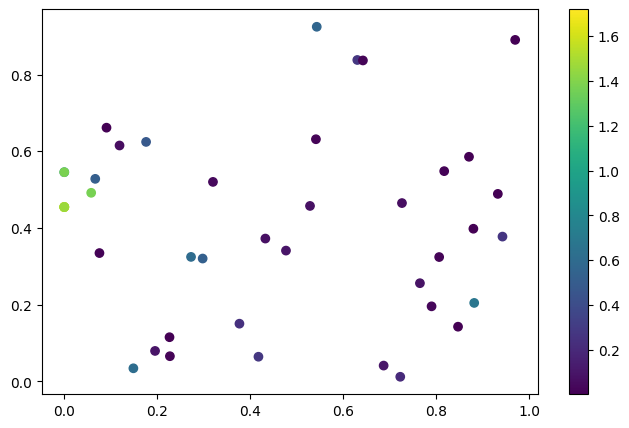

In [66]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()

Text(0.5, 0.92, 'Scatter Plot of Contamination Sources Input Data Points with Output Variable y')

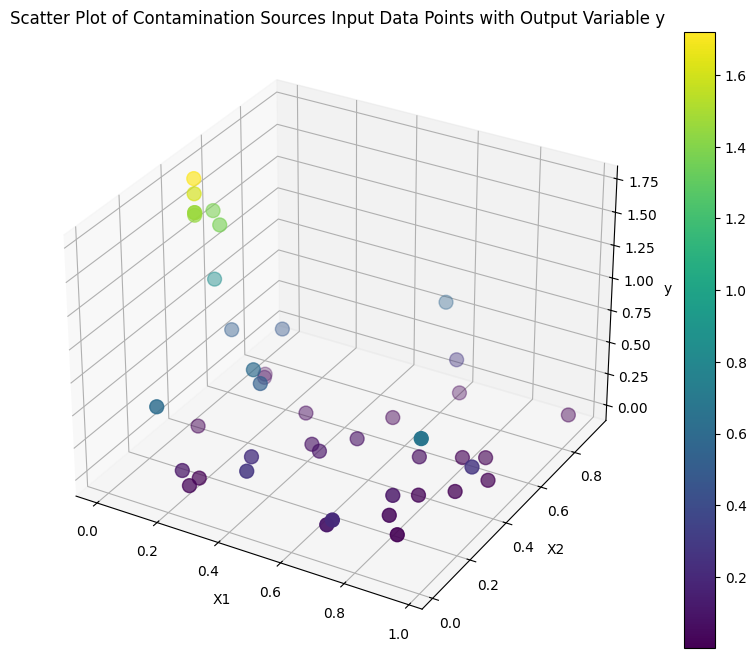

In [67]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis', s=100)

plt.colorbar(sc)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

ax.set_title('Scatter Plot of Contamination Sources Input Data Points with Output Variable y')


**Acquisition Functions**

In [68]:
#UCB is useful when you want a balance between exploring new areas of the search space (high uncertainty) and exploiting known areas 
#with high mean values. The parameter β controls this balance. It's a good general-purpose acquisition function for many optimization problems.
def upper_confidence_bound(post_mean, post_std, beta):
    ucb = post_mean + beta * post_std # upper confidence bpon (ucb) = mu + kappa * sigma 
    print("\n\nUCB Shape: ", np.shape(ucb))
    return ucb


#PI is more focused on exploitation, as it prioritizes areas where the predicted mean is higher than the current best observed value (ymax)
#Use PI when you have a well-calibrated model and you want to focus on improving the best observed value.
def probability_of_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI Shape: ", np.shape(PI))
    return PI


def probability_of_improvement_with_exploration_term(post_mean, post_std, y_max, epsilon):
    # Calculate the improvement with exploration term
    improvement = post_mean - (y_max + epsilon)
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI With Exploitation Term Shape: ", np.shape(PI))
    return PI


#EI provides a balance between exploration and exploitation, similar to UCB, but it also considers the magnitude of improvement.
#Use EI when you want to maximize the expected improvement over the current best observed value.
def expected_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the expected improvement
    EI = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    print("\n\nEI Shape: ", np.shape(EI))
    return EI

#Thompson Sampling is useful when you want to sample from the posterior distribution of the model, which inherently balances exploration and exploitation.
#Use Thompson Sampling when you want a stochastic approach to selecting the next point.
def thompson_sampling(post_mean, post_std):
    # Sample from the posterior distribution
    samples = np.random.normal(post_mean, post_std)
    print("\n\nThompson Samples Shape: ", np.shape(samples))
    return samples

**Input Sampling Methods**

In [69]:
def exploration_grid():
    x1_grid = np.linspace(0.000001, 0.999999, 10)
    x2_grid = np.linspace(0.000001, 0.999999, 10)
    x3_grid = np.linspace(0.000001, 0.999999, 10)
    x4_grid = np.linspace(0.000001, 0.999999, 10)
    x5_grid = np.linspace(0.000001, 0.999999, 10)
    x6_grid = np.linspace(0.000001, 0.999999, 10)

    x1_grid, x2_grid, x3_grid, x4_grid, x5_grid, x6_grid = np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid, x5_grid, x6_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(),  x4_grid.ravel(),  x5_grid.ravel(),  x6_grid.ravel()]).T

    return x_grid

def exploitation_grid(center, delta=0.05):
    """
    Create a grid for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    x1, x2, x3, x4, x5, x6 = center
    x1_grid = np.linspace(max(0.000001, x1 - delta), min(0.999999, x1 + delta), 10)
    x2_grid = np.linspace(max(0.000001, x2 - delta), min(0.999999, x2 + delta), 10)
    x3_grid = np.linspace(max(0.000001, x3 - delta), min(0.999999, x3 + delta), 10)
    x4_grid = np.linspace(max(0.000001, x4 - delta), min(0.999999, x4 + delta), 10)
    x5_grid = np.linspace(max(0.000001, x5 - delta), min(0.999999, x5 + delta), 10)
    x6_grid = np.linspace(max(0.000001, x6 - delta), min(0.999999, x6 + delta), 10)

    x1_grid, x2_grid, x3_grid, x4_grid, x5_grid, x6_grid = np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid, x5_grid, x6_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(), x4_grid.ravel(), x5_grid.ravel(),  x6_grid.ravel()]).T

    return x_grid

def exploration_latin_hypercube():
    """
    Create a Latin Hypercube sample for exploration.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (0.000001, 0.999999),  # x1
        (0.000001, 0.999999),  # x2
        (0.000001, 0.999999),  # x3
        (0.000001, 0.999999),  # x4
        (0.000001, 0.999999),  # x5
        (0.000001, 0.999999)   # x6
    ]
    sampler = qmc.LatinHypercube(d=6)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

def exploitation_latin_hypercube(center, delta=0.05):
    """
    Create a Latin Hypercube sample for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (max(0.000001, center[0] - delta), min(0.999999, center[0] + delta)),  # x1
        (max(0.000001, center[1] - delta), min(0.999999, center[1] + delta)),  # x2
        (max(0.000001, center[2] - delta), min(0.999999, center[2] + delta)),  # x3
        (max(0.000001, center[3] - delta), min(0.999999, center[3] + delta)),  # x4
        (max(0.000001, center[4] - delta), min(0.999999, center[4] + delta)),  # x5
        (max(0.000001, center[5] - delta), min(0.999999, center[5] + delta))   # x6
    ]
    sampler = qmc.LatinHypercube(d=6)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

In [70]:
def query_black_box_function_with_default_kernel(X, y, x_grid, acquisition_func):
    
    beta = 1.96
    model = GaussianProcessRegressor()
    model.fit(X, y)
       
    post_mean, post_std = model.predict(x_grid, return_std=True) #post_mean is y_pred and post_std is sigma i.e. s
    #acquisition_function = post_mean + beta * post_std # upper confidence bound (ucb) = mu + kappa * sigma mu + kappa * sigma 
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
        
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)  # Define y_max as the maximum observed value
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
        
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)

    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)

    else: #thompson_sampling
         acquisition_function = acquisition_func(post_mean, post_std)
    
    next_query = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]
    
    next_query = next_query.reshape(1,6)
    y_pred = np.array([y_pred])
    
    print(f"Query to Black Box Function Maximizes at Input: ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}-{next_query[0][5]:.6f})")
    print(f"Predicted Value at ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}-{next_query[0][5]:.6f}) is {y_pred[0]})") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
   
    return next_query, y_pred

In [71]:
def next_query_with_default_kernel(X, y, x_grid):
    x_random = np.random.uniform(size = 2)
    print(f"Random Query: {x_random[0]:.6f}-{x_random[1]:.6f}")

    x_ucb, y_pred_ucb = query_black_box_function_with_default_kernel(X, y, x_grid, upper_confidence_bound)
    
    x_pi, y_pred_pi = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement)
    
    x_piet, y_pred_piet = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement_with_exploration_term)
    
    x_ei, y_pred_ei = query_black_box_function_with_default_kernel(X, y, x_grid, expected_improvement)
    
    x_ts, y_pred_ts = query_black_box_function_with_default_kernel(X, y, x_grid, thompson_sampling)

    return x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts

**Exploration**

Explore the whole space with **defalut** RBF Kernel

In [72]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploration_grid())

Random Query: 0.252619-0.561419


UCB Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999-0.000001-0.555555-0.999999-0.000001)
Predicted Value at (0.000001-0.999999-0.000001-0.555555-0.999999-0.000001) is 2.774105068974677)
Index of maximum acquisition function value:  900590


PI Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.333334-0.222223-0.666666)
Predicted Value at (0.000001-0.000001-0.000001-0.333334-0.222223-0.666666) is 2.910438560596617)
Index of maximum acquisition function value:  326


PI With Exploitation Term Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.111112-0.222223-0.333334-0.222223-0.666666)
Predicted Value at (0.000001-0.111112-0.222223-0.333334-0.222223-0.666666) is 2.797175532257711)
Index of maximum acquisition function value:  102326


EI Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.333334-0.11

**Exploitation**

In [73]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.0020793804007888804
Best query so far: [0.870438 0.585604 0.527818 0.437121 0.914961 0.723941]


In [74]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploitation_grid(best_query_so_far))

Random Query: 0.485092-0.369496


UCB Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.920438-0.635604-0.577818-0.487121-0.864961-0.773941)
Predicted Value at (0.920438-0.635604-0.577818-0.487121-0.864961-0.773941) is 0.3019538577601111)
Index of maximum acquisition function value:  999909


PI Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.820438-0.635604-0.577818-0.487121-0.864961-0.773941)
Predicted Value at (0.820438-0.635604-0.577818-0.487121-0.864961-0.773941) is 0.2405739909379463)
Index of maximum acquisition function value:  909909


PI With Exploitation Term Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.820438-0.535604-0.477818-0.387121-0.864961-0.673941)
Predicted Value at (0.820438-0.535604-0.477818-0.387121-0.864961-0.673941) is -0.10501991267739186)
Index of maximum acquisition function value:  0


EI Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.820438-0.635604-0.577818-0.487121-0

**Hyperparameter Tuning using gp_minimize**

In [75]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, DotProduct
def query_black_box_function_with_hyper_parameters(X, y, x_grid, acquisition_func, kernel_type, rbf_lengthscale, noise_assumption, restarts, beta):
    # Define the kernel based on the kernel_type parameter
    if kernel_type == 'RBF':
        kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2)) * C(1.0, (1e-10, 1e10))

    elif kernel_type == 'Matern':
        kernel = Matern(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2), nu=1.5)

    elif kernel_type == 'RationalQuadratic':
        kernel = RationalQuadratic(length_scale=rbf_lengthscale, alpha=1.0) * C(1.0, (1e-10, 1e10))
      
    elif kernel_type == 'DotProduct':
        kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) + C(1.0, (1e-10, 1e10))
    else:
        kernel = None

    # Create and fit the Gaussian Process model
    if kernel is None:
        model = GaussianProcessRegressor()
    else:   
        model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption, n_restarts_optimizer=restarts)

    model.fit(X, y)

    # Predict the mean and standard deviation
    post_mean, post_std = model.predict(x_grid, return_std=True)

    # Compute the acquisition function
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)
    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    else:  # thompson_sampling
        acquisition_function = acquisition_func(post_mean, post_std)

    # Find the point that maximizes the acquisition function
    next_query = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]

    next_query = next_query.reshape(1, 6)
    y_pred = np.array([y_pred])

    print(f"Query to Black Box Function Maximizes at Input: ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}-{next_query[0][5]:.6f})")
    print(f"Predicted Value at ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}-{next_query[0][5]:.6f}) is {y_pred[0]})") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel Type:", kernel_type)

    return next_query, y_pred

**Hyperparameter Tuning using gp_minimize**

With Full Grid as Search Space

In [76]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

x_grid = exploration_grid()


# Define the search space
search_space = [
    Real(0.01, 1.0, name='lengthscale'),
    Real(1e-10, 1e-1, name='noise_assumption'),
    Integer(0, 15, name='restarts'),
    Real(1.0, 3.0, name='beta'),
    Categorical([upper_confidence_bound, probability_of_improvement, 
                 probability_of_improvement_with_exploration_term, 
                 expected_improvement, thompson_sampling], name='acquisition_func'),
    Categorical(['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'], name='kernel_type')
]

# Define the objective function
@use_named_args(search_space)
def objective_function_gp(lengthscale, noise_assumption, restarts, beta, acquisition_func, kernel_type):
    global best_x_ucb, best_y_pred_ucb, best_params

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, x_grid,
        acquisition_func=acquisition_func,
        kernel_type=kernel_type,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=restarts,
        beta=beta
    )
    
    # Return the absolute value of the prediction as we want to get as close to zero as possible
    return np.abs(y_pred[0])

# Perform Bayesian optimization
result = gp_minimize(
    func=objective_function_gp,
    dimensions=search_space,
    n_calls=50,  # Number of evaluations
    random_state=42
)

# Extract the best parameters
(best_rbf_lengthscale, best_noise_assumption, best_restarts, 
 best_beta, best_acquisition_func, best_kernel_type) = result.x
print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, acquisition_func={best_acquisition_func.__name__}, "
      f"kernel_type={best_kernel_type}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, x_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale, 
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


PI With Exploitation Term Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.111112-0.222223-0.333334-0.222223-0.666666)
Predicted Value at (0.000001-0.111112-0.222223-0.333334-0.222223-0.666666) is 2.797175532257711)
Index of maximum acquisition function value:  102326
Kernel Type: None


UCB Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.333334-0.333334-0.222223-0.333334-0.777777)
Predicted Value at (0.000001-0.333334-0.333334-0.222223-0.333334-0.777777) is 1.3630930280762672)
Index of maximum acquisition function value:  303237
Kernel Type: RationalQuadratic


EI Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.333334-0.111112-0.777777)
Predicted Value at (0.000001-0.000001-0.000001-0.333334-0.111112-0.777777) is 3.0184898729862653)


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)




Thompson Samples Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.555555-0.111112-0.999999-0.777777-0.555555-0.777777)
Predicted Value at (0.555555-0.111112-0.999999-0.777777-0.555555-0.777777) is 4.4256016511415994e-204)
Index of maximum acquisition function value:  159757
Kernel Type: RBF


Thompson Samples Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.333334-0.777777-0.111112-0.111112-0.888888)
Predicted Value at (0.000001-0.333334-0.777777-0.111112-0.111112-0.888888) is 0.7947966345133066)
Index of maximum acquisition function value:  307118
Kernel Type: RBF


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




UCB Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.444445-0.333334-0.000001-0.888888-0.999999-0.111112)
Predicted Value at (0.444445-0.333334-0.000001-0.888888-0.999999-0.111112) is 5.522780801610161e-07)
Index of maximum acquisition function value:  340891
Kernel Type: RBF


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




UCB Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.444445-0.333334-0.000001-0.888888-0.999999-0.111112)
Predicted Value at (0.444445-0.333334-0.000001-0.888888-0.999999-0.111112) is 5.292768062022071e-07)
Index of maximum acquisition function value:  340891
Kernel Type: RBF
Best Parameters: rbf_lengthscale=1.0, noise_assumption=1e-10, restarts=15, beta=1.0, acquisition_func=thompson_sampling, kernel_type=RBF


Thompson Samples Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.222223-0.111112-0.111112-0.333334-0.222223-0.666666)
Predicted Value at (0.222223-0.111112-0.111112-0.333334-0.222223-0.666666) is 0.6835715837555802)
Index of maximum acquisition function value:  121326
Kernel Type: RBF


(array([[0.22222278, 0.11111189, 0.11111189, 0.33333367, 0.22222278,
         0.66666633]]),
 array([0.68357158]))

**Exploration**

Explore the whole grid as search space with Best Hyperparameters found using **gp_minimize**

In [77]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_grid(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



Thompson Samples Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.222223-0.222223-0.222223-0.222223-0.555555)
Predicted Value at (0.000001-0.222223-0.222223-0.222223-0.222223-0.555555) is 1.3037774145099021)
Index of maximum acquisition function value:  202225
Kernel Type: RBF


(array([[1.00000000e-06, 2.22222778e-01, 2.22222778e-01, 2.22222778e-01,
         2.22222778e-01, 5.55555444e-01]]),
 array([1.30377741]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **gp_minimize**

In [78]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.0020793804007888804
Best query so far: [0.870438 0.585604 0.527818 0.437121 0.914961 0.723941]


In [79]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_grid(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



Thompson Samples Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.920438-0.546715-0.477818-0.398232-0.864961-0.773941)
Predicted Value at (0.920438-0.546715-0.477818-0.398232-0.864961-0.773941) is 0.0054162884288673)
Index of maximum acquisition function value:  190109
Kernel Type: RBF


(array([[0.920438  , 0.54671511, 0.477818  , 0.39823211, 0.864961  ,
         0.773941  ]]),
 array([0.00541629]))

**Hyperparameter Tuning with BayesianOptimization**

With Full Grid as Search Space

In [80]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

x_grid = exploration_grid()

# Define the function to optimize
def objective_function_bo(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, x_grid,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative absolute value of the prediction as we want to get as close to zero as possible
    return -np.abs(y_pred[0])

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 4),  # 0:None, 1: RBF, 2: Matern, 3: RationalQuadratic, 4: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, x_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip




PI Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.333334-0.222223-0.222223-0.333334-0.666666)
Predicted Value at (0.000001-0.333334-0.222223-0.222223-0.333334-0.666666) is 1.3882529100633372)
Index of maximum acquisition function value:  302236
Kernel Type: RationalQuadratic
| 1         | -1.388    | 1.498     | 2.901     | 2.928     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.111112-0.222223-0.000001-0.999999)
Predicted Value at (0.000001-0.000001-0.111112-0.222223-0.000001-0.999999) is 1.1494628826614042)
Index of maximum acquisition function value:  1209
Kernel Type: Matern
| 2         | -1.149    | 0.2323    | 2.732     | 2.404     | 0.711     | 0.002058  | 14.55     |


EI Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.222223-0.333334-0.222223-0.333334-0.777777)
Predicted Value at (0.000001-0.222223-0.333334-0.222223-0.333334-0.7

(array([[1.00000000e-06, 4.44444556e-01, 1.00000000e-06, 1.11111889e-01,
         2.22222778e-01, 5.55555444e-01]]),
 array([0.91450354]))

**Exploration**

Explore the whole grid as search space with Best Hyperparameters found using **BayesianOptimization**

In [81]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_grid(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



Thompson Samples Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.111112-0.000001-0.666666-0.000001-0.999999)
Predicted Value at (0.000001-0.111112-0.000001-0.666666-0.000001-0.999999) is 0.48993496514774965)
Index of maximum acquisition function value:  100609
Kernel Type: RationalQuadratic


(array([[1.00000000e-06, 1.11111889e-01, 1.00000000e-06, 6.66666333e-01,
         1.00000000e-06, 9.99999000e-01]]),
 array([0.48993497]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **BayesianOptimization**

In [82]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.0020793804007888804
Best query so far: [0.870438 0.585604 0.527818 0.437121 0.914961 0.723941]


In [83]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_grid(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



Thompson Samples Shape:  (1000000,)
Query to Black Box Function Maximizes at Input: (0.875994-0.624493-0.555596-0.431565-0.887183-0.762830)
Predicted Value at (0.875994-0.624493-0.555596-0.431565-0.887183-0.762830) is 0.05580515816608511)
Index of maximum acquisition function value:  857428
Kernel Type: RationalQuadratic


(array([[0.87599356, 0.62449289, 0.55559578, 0.43156544, 0.88718322,
         0.76282989]]),
 array([0.05580516]))

**Hyperparameter Tuning using BayesianOptimization]**

Latin Hypercube Sampling

In [84]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

lhs_samples = exploration_latin_hypercube()

# Define the function to optimize
def objective_function_bo_lhs(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, lhs_samples,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative absolute value of the prediction as we want to get as close to zero as possible
    return -np.abs(y_pred[0])

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 4),  # 0:None, 1: RBF, 2: Matern, 3: RationalQuadratic, 4: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo_lhs,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, lhs_samples,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.071658-0.358091-0.482529-0.285475-0.340602-0.756234)
Predicted Value at (0.071658-0.358091-0.482529-0.285475-0.340602-0.756234) is 1.0741545395351018)
Index of maximum acquisition function value:  9442
Kernel Type: RationalQuadratic
| 1         | -1.074    | 1.498     | 2.901     | 2.928     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.020509-0.072804-0.128985-0.208070-0.330856-0.707108)
Predicted Value at (0.020509-0.072804-0.128985-0.208070-0.330856-0.707108) is 1.5246435877556586)
Index of maximum acquisition fu

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)




PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.034703-0.105481-0.369158-0.152374-0.297202-0.806328)
Predicted Value at (0.034703-0.105481-0.369158-0.152374-0.297202-0.806328) is 0.8684724479411063)
Index of maximum acquisition function value:  9838
Kernel Type: RationalQuadratic
| 6         | -0.8685   | 1.646     | 1.905     | 2.561     | 0.2578    | 0.02662   | 4.641     |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.037411-0.205656-0.300908-0.272791-0.167526-0.646407)
Predicted Value at (0.037411-0.205656-0.300908-0.272791-0.167526-0.646407) is 2.6412375977901092)
Index of maximum acquisition function value:  2279
Kernel Type: None
| 7         | -2.641    | 0.0       | 1.0       | 0.0       | 0.01      | 0.1       | 4.095     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.611886-0.450397-0.953882-0.098200-0.696606-0.562615)
Predicted Value at (0.611886-0.450397-0.953882-0.098200

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.078166-0.956145-0.146559-0.005997-0.239398-0.954158)
Predicted Value at (0.078166-0.956145-0.146559-0.005997-0.239398-0.954158) is 1.4370729991594828)
Index of maximum acquisition function value:  7466
Kernel Type: DotProduct
| 50        | -1.437    | 2.817     | 1.56      | 3.696     | 0.1125    | 0.04401   | 5.442     |


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:478: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(
C:\Users\harji\AppData\Local\Temp\ipykernel_29820\3886067424.py:16: RuntimeWarning: divide by zero encountered in divide
  Z = improvement / post_std




PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.611886-0.450397-0.953882-0.098200-0.696606-0.562615)
Predicted Value at (0.611886-0.450397-0.953882-0.098200-0.696606-0.562615) is 0.0625)
Index of maximum acquisition function value:  0
Kernel Type: DotProduct
| 51        | -0.0625   | 1.045     | 3.0       | 3.617     | 1.0       | 1e-10     | 7.99      |


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.074023-0.955068-0.194289-0.138840-0.274179-0.971721)
Predicted Value at (0.074023-0.955068-0.194289-0.138840-0.274179-0.971721) is 1.3517669852583793)
Index of maximum acquisition function value:  4317
Kernel Type: DotProduct
| 52        | -1.352    | 3.987     | 2.415     | 3.95      | 0.1633    | 0.0704    | 5.896     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.611886-0.450397-0.953882-0.098200-0.696606-0.562615)
Predicted Value at (0.611886-0.450397-0.953882-0.098200-0.696606-0.562615) is 0.2

(array([[0.61188592, 0.45039681, 0.95388238, 0.09820041, 0.69660584,
         0.56261471]]),
 array([0.21317101]))

**Exploration**

Explore the Latin Hypescale search space with Best Hyperparameters found using **BaysianOptimization on Latin Hypescale Search Space**

In [85]:

next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_latin_hypercube(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.803774-0.200233-0.614538-0.991000-0.783814-0.021558)
Predicted Value at (0.803774-0.200233-0.614538-0.991000-0.783814-0.021558) is -0.6152629852294922)
Index of maximum acquisition function value:  0
Kernel Type: DotProduct


(array([[0.8037741 , 0.2002333 , 0.6145384 , 0.99099976, 0.78381435,
         0.02155772]]),
 array([-0.61526299]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **BayesianOptimization on Latin Hypescale Search Space**

In [86]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.0020793804007888804
Best query so far: [0.870438 0.585604 0.527818 0.437121 0.914961 0.723941]


In [87]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_latin_hypercube(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.872068-0.626226-0.572183-0.483155-0.891554-0.759159)
Predicted Value at (0.872068-0.626226-0.572183-0.483155-0.891554-0.759159) is 0.125)
Index of maximum acquisition function value:  0
Kernel Type: DotProduct


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:478: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(
C:\Users\harji\AppData\Local\Temp\ipykernel_29820\3886067424.py:16: RuntimeWarning: divide by zero encountered in divide
  Z = improvement / post_std


(array([[0.87206847, 0.6262258 , 0.57218306, 0.4831549 , 0.89155411,
         0.7591592 ]]),
 array([0.125]))